In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [8]:
# Read the dataset
df=pd.read_csv("/kaggle/input/datasets/csdeeraj/gaming-laptop-purchase-prediction/Gaming_Laptop_Purchase_DTC.csv")

In [9]:
# Display the first five rows
df.head()

,Age,Student,MonthlyIncome,GamingHoursPerWeek,OwnsDesktop,TechInterest,PurchasedLaptop
0,25,Yes,52000,16,No,High,Yes
1,52,Yes,72000,3,Yes,Medium,No
2,19,Yes,108000,35,No,Medium,Yes
3,18,No,72000,22,No,Medium,Yes
4,24,Yes,30000,23,No,High,Yes


In [10]:
# Display information about the dataset
df.info()
# Check for missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 100 non-null    int64 
 1   Student             100 non-null    object
 2   MonthlyIncome       100 non-null    int64 
 3   GamingHoursPerWeek  100 non-null    int64 
 4   OwnsDesktop         100 non-null    object
 5   TechInterest        100 non-null    object
 6   PurchasedLaptop     100 non-null    object
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


Age                   0
Student               0
MonthlyIncome         0
GamingHoursPerWeek    0
OwnsDesktop           0
TechInterest          0
PurchasedLaptop       0
dtype: int64

In [11]:
# Convert text values into numbers
encoder=LabelEncoder()

df["Student"]=encoder.fit_transform(df["Student"])
df["OwnsDesktop"]=encoder.fit_transform(df["OwnsDesktop"])
df["TechInterest"]=encoder.fit_transform(df["TechInterest"])
df["PurchasedLaptop"]=encoder.fit_transform(df["PurchasedLaptop"])

df.head()

,Age,Student,MonthlyIncome,GamingHoursPerWeek,OwnsDesktop,TechInterest,PurchasedLaptop
0,25,1,52000,16,0,0,1
1,52,1,72000,3,1,2,0
2,19,1,108000,35,0,2,1
3,18,0,72000,22,0,2,1
4,24,1,30000,23,0,0,1


In [12]:
# Select the input and output
X=df.drop("PurchasedLaptop",axis=1)
y=df["PurchasedLaptop"]

In [13]:
# Split the dataset
Xtrain,Xtest,ytrain,ytest=train_test_split(
    X,y,test_size=0.2,random_state=42
)
# Create and train the decision tree
model=DecisionTreeClassifier(max_depth=4,random_state=42)

model.fit(Xtrain,ytrain)

print("Model trained successfully.")
# Predict the test data
ypred=model.predict(Xtest)

print(ypred)

Model trained successfully.
[1 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1]


In [14]:
# Display the accuracy
accuracy=accuracy_score(ytest,ypred)

print("Accuracy :",accuracy)
# Display the classification report
print(classification_report(ytest,ypred))

Accuracy : 0.7
              precision    recall  f1-score   support

           0       0.40      0.40      0.40         5
           1       0.80      0.80      0.80        15

    accuracy                           0.70        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.70      0.70      0.70        20



In [15]:
# Display the confusion matrix
cm=confusion_matrix(ytest,ypred)

print(cm)

[[ 2  3]
 [ 3 12]]


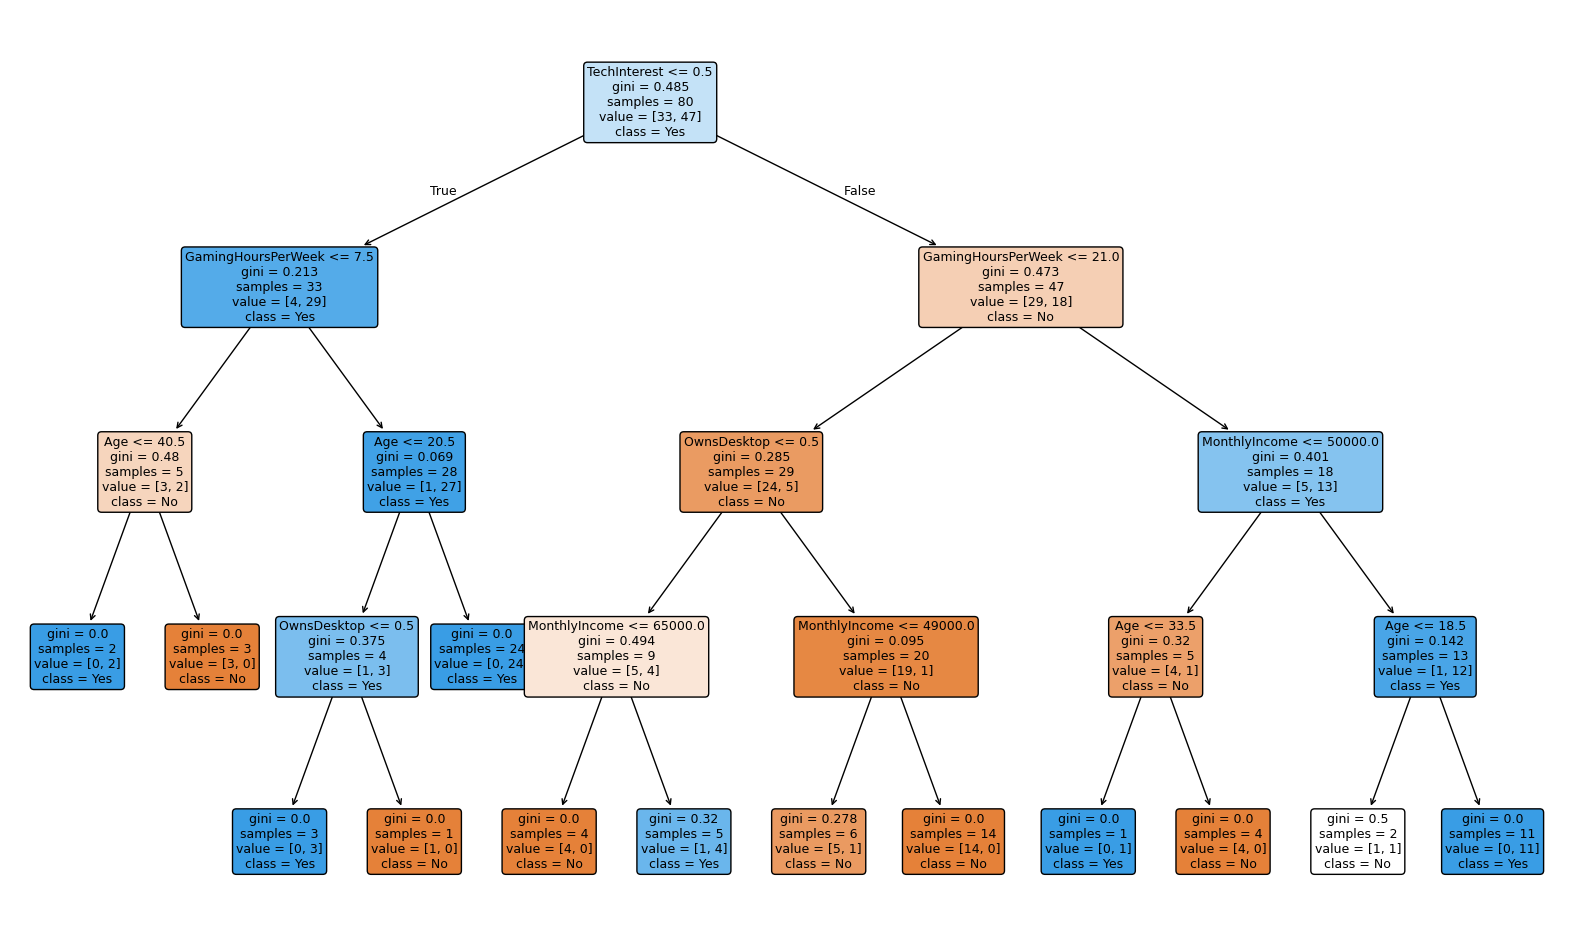

In [16]:
# Display the decision tree
plt.figure(figsize=(20,12))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No","Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

In [17]:
age=int(input("Enter Age : "))
student=input("Student (Yes/No) : ")
income=int(input("Enter Monthly Income : "))
gaming=int(input("Enter Gaming Hours Per Week : "))
desktop=input("Owns Desktop (Yes/No) : ")
tech=input("Tech Interest (Low/Medium/High) : ")

student=1 if student=="Yes" else 0
desktop=1 if desktop=="Yes" else 0

techmap={"Low":0,"Medium":1,"High":2}
tech=techmap[tech]

result=model.predict([[age,student,income,gaming,desktop,tech]])

if result[0]==1:
    print("Prediction : Customer is likely to purchase a gaming laptop.")
else:
    print("Prediction : Customer is not likely to purchase a gaming laptop.")

Enter Age :  24
Student (Yes/No) :  Yes
Enter Monthly Income :  55000
Enter Gaming Hours Per Week :  22
Owns Desktop (Yes/No) :  No
Tech Interest (Low/Medium/High) :  High


Prediction : Customer is likely to purchase a gaming laptop.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
